In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
from collections import Counter
import matplotlib.pyplot as plt

In [30]:
DECISION_MODEL_PATH = "../weights/decision_model.h5"
FACE_MODEL_PATH = "../weights/art_baseline_model.h5"
ANIMAL_MODEL_PATH = "../weights/art_baseline_model.h5"
ART_MODEL_PATH = "../weights/art_best_model.h5"

TEST_DIR = "../dataset_test/"

BATCH_SIZE = 32

In [ ]:
decision_model = tf.keras.models.load_model(DECISION_MODEL_PATH)
face_expert = tf.keras.models.load_model(FACE_MODEL_PATH)
animal_expert = tf.keras.models.load_model(ANIMAL_MODEL_PATH)
art_expert = tf.keras.models.load_model(ART_MODEL_PATH)

experts = [animal_expert, art_expert,face_expert]
experts_names = ["animals", "art","faces"]

## Load testing data

In [32]:
raw_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(200, 200), 
    batch_size=BATCH_SIZE,
    shuffle=False
)
high_level_names = raw_ds.class_names  

print("High level labels: ", high_level_names)

Found 75589 files belonging to 3 classes.
High level labels:  ['animals', 'art', 'faces']


In [33]:
def attach_fake_real(image, hl_label):
    parts = tf.strings.split(image.file_path, os.sep)
    fr_label = tf.where(parts[-2] == "fake", 0, 1) 
    return image, (hl_label, fr_label)


def decode_and_label(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (200, 200))
    img = img / 255.0

    parts = tf.strings.split(path, os.sep)
    # i.e ["dataset_test", "animals", "fake", "img_1.jpg"]
    hl_name = parts[-3] 
    fr_name = parts[-2] 
    hl_idx = tf.cast(tf.where(hl_name == high_level_names)[0][0], tf.int32)
    fr_idx = tf.cast(tf.where(fr_name == ["fake", "real"])[0][0], tf.int32)
    return img, (hl_idx, fr_idx)


# take all image paths
all_files = tf.data.Dataset.list_files(str(TEST_DIR + "*/*/*.jpg"), shuffle=True, seed=109)

test_ds = all_files.map(decode_and_label, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

total_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Total batches: ", total_batches)

Total batches:  2363


In [34]:
#for future analytics
def count_category_distribution(test_dir, high_level_names):
    category_counts = Counter()
    for hl in high_level_names:
        hl_path = os.path.join(test_dir, hl)
        for subcat in ["fake", "real"]:
            full_path = os.path.join(hl_path, subcat)
            if os.path.exists(full_path):
                category_counts[hl] += len([
                    f for f in os.listdir(full_path) 
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))
                ])
    return category_counts


category_counts = count_category_distribution(TEST_DIR, high_level_names)
original_distribution = [category_counts.get(name, 0) for name in high_level_names]
total_original = sum(original_distribution)
original_distribution_norm = [count / total_original for count in original_distribution]


## Hard-gating

In [35]:
class MoEModel(tf.keras.Model):
    def __init__(self, gate, experts):
        super().__init__()
        self.gate = gate      
        self.experts = experts 
        self.num_experts = len(experts)


    def call(self, x, training=False):
        gate_logits = self.gate(x, training=training)  

        # convert to probabilities
        gate_probs = tf.nn.softmax(gate_logits, axis=-1) 

        expert_idx = tf.argmax(gate_probs, axis=-1)  

        # experts output
        expert_outputs = []
        for expert in self.experts:
            expert_output = expert(x, training=training)
            expert_outputs.append(expert_output)

        # stack all expert outputs
        stacked = tf.stack(expert_outputs, axis=1)
        mask = tf.one_hot(expert_idx, depth=self.num_experts)
        mask = tf.expand_dims(mask, -1)  

        output = tf.reduce_sum(stacked * mask, axis=1)  

        # analytics 
        self.last_gate_probs = gate_probs
        self.last_expert_idx = expert_idx

        return output

    def get_routing_distribution(self):
        """Return the distribution of examples across experts"""
        if hasattr(self, 'last_expert_idx'):
            counts = []
            for i in range(self.num_experts):
                count = tf.reduce_sum(
                    tf.cast(tf.equal(self.last_expert_idx, i), tf.float32))
                counts.append(count)
            total = tf.reduce_sum(counts)
            return [count / total for count in counts]
        return None

In [36]:
def evaluate_moe(model, test_ds, subset_ratio=1.0):
    """
    Evaluate MoE model on a subset of the test dataset using simple arrays
    
    Args:
        model: The MoE model to evaluate
        test_ds: TensorFlow dataset containing test data
        subset_ratio: Fraction of the dataset to evaluate (0.0-1.0)
    
    Returns:
        Dictionary of evaluation metrics
    """
    hl_correct = 0
    hl_total = 0
    fr_correct = 0
    fr_total = 0
    expert_counts = [0] * model.num_experts

    batch_count = 0
    max_batches = None

    # subset ratio
    if subset_ratio < 1.0:
        max_batches = int(total_batches * subset_ratio)
        
    print(f"Evaluating on {max_batches if max_batches else total_batches} batches...")

    for batch_imgs, (batch_hl_true, batch_fr_true) in test_ds:
        if (batch_count +1) % 50 == 0:
            print(f"Processing batch {batch_count + 1}...")
        batch_count += 1
        if max_batches is not None and batch_count > max_batches:
            break

        # moe predictions
        fr_logits = model(batch_imgs, training=False)

        # fake/real predictions
        fr_probs = tf.sigmoid(fr_logits).numpy()
        fr_pred = (fr_probs > 0.5).astype(int)
        if len(fr_pred.shape) > 1:
            fr_pred = fr_pred.squeeze()

        # for analysis, get the gate logits
        gate_logits = model.gate(batch_imgs, training=False).numpy()
        
        hl_pred = np.argmax(gate_logits, axis=-1)
        
        batch_hl_true = batch_hl_true.numpy()
        batch_fr_true = batch_fr_true.numpy()

        batch_hl_true_zero_based = batch_hl_true - 1

        hl_correct += np.sum(hl_pred == batch_hl_true_zero_based)
        hl_total   += len(batch_hl_true_zero_based)

        # fake/real accuracy
        fr_correct += np.sum(fr_pred == batch_fr_true)
        fr_total += len(batch_fr_true)

        for i in range(model.num_experts):
            expert_counts[i] += np.sum(hl_pred == i)

    # metrics
    hl_accuracy = hl_correct / hl_total if hl_total > 0 else 0
    fr_accuracy = fr_correct / fr_total if fr_total > 0 else 0

    # expert distribution
    total_examples = sum(expert_counts)
    expert_distribution = [count / total_examples for count in expert_counts] if total_examples > 0 else [0] * model.num_experts

    print(f"Evaluated on {batch_count} batches ({subset_ratio:.2f} of test set)")
    print(f"High-level routing accuracy: {hl_accuracy:.3f}")
    print(f"Fake vs Real detection accuracy: {fr_accuracy:.3f}")
    print(f"Expert usage counts: {expert_counts}")
    print(f"Expert distribution: {[f'{dist:.2f}' for dist in expert_distribution]}")

    return {'high_level_accuracy': hl_accuracy,'fake_real_accuracy': fr_accuracy,'expert_counts': expert_counts,'expert_distribution': expert_distribution,'batches_evaluated': batch_count}

In [37]:
moe = MoEModel(gate=decision_model,experts=experts)


metrics = evaluate_moe(moe, test_ds,subset_ratio=1)


Evaluating on 2363 batches...
Processing batch 50...
Processing batch 100...
Processing batch 150...
Processing batch 200...
Processing batch 250...
Processing batch 300...
Processing batch 350...
Processing batch 400...
Processing batch 450...
Processing batch 500...
Processing batch 550...
Processing batch 600...
Processing batch 650...
Processing batch 700...
Processing batch 750...
Processing batch 800...
Processing batch 850...
Processing batch 900...
Processing batch 950...
Processing batch 1000...
Processing batch 1050...
Processing batch 1100...
Processing batch 1150...
Processing batch 1200...
Processing batch 1250...
Processing batch 1300...
Processing batch 1350...
Processing batch 1400...
Processing batch 1450...
Processing batch 1500...
Processing batch 1550...
Processing batch 1600...
Processing batch 1650...
Processing batch 1700...
Processing batch 1750...
Processing batch 1800...
Processing batch 1850...
Processing batch 1900...
Processing batch 1950...
Processing batc

/tmp/ipykernel_14085/2937665201.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(high_level_names, rotation=45)
/tmp/ipykernel_14085/2937665201.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels([f'Expert {experts_names[i]}' for i in range(len(expert_distribution))], rotation=45)


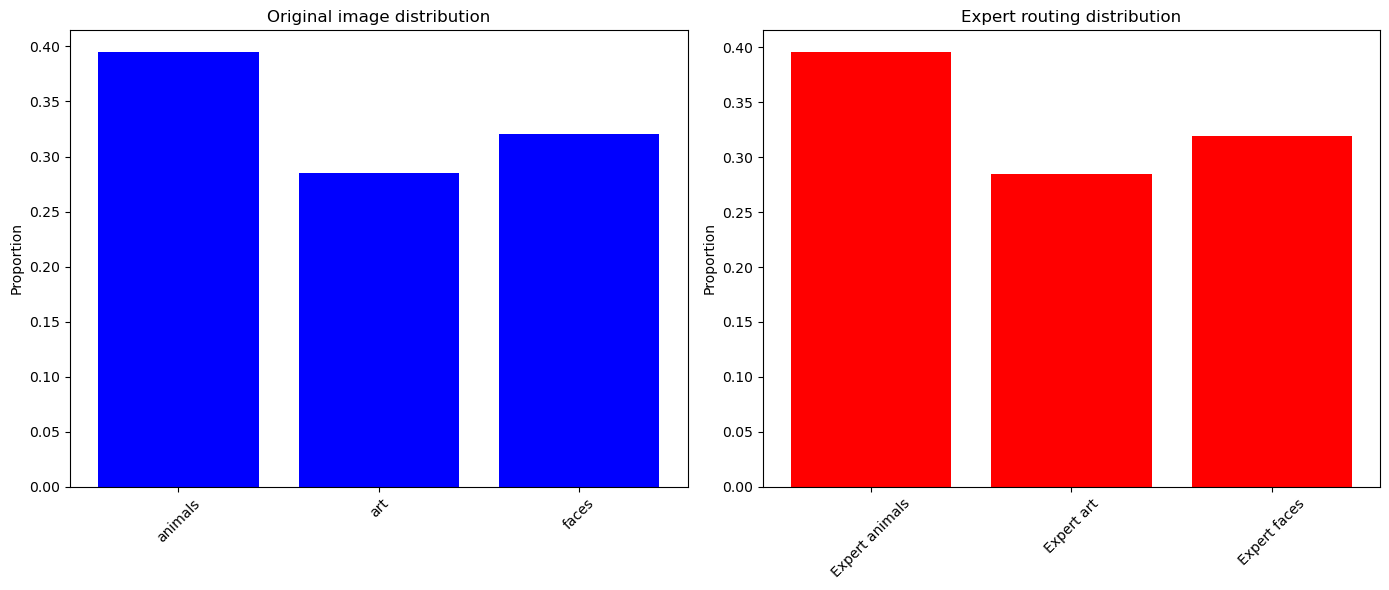

In [38]:
expert_distribution = metrics['expert_distribution']

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].bar(high_level_names, original_distribution_norm, color='blue')
axs[0].set_title('Original image distribution')
axs[0].set_ylabel('Proportion')
axs[0].set_xticklabels(high_level_names, rotation=45)

axs[1].bar([f'Expert {experts_names[i]}' for i in range(len(expert_distribution))], expert_distribution, color='red')
axs[1].set_title('Expert routing distribution')
axs[1].set_ylabel('Proportion')
axs[1].set_xticklabels([f'Expert {experts_names[i]}' for i in range(len(expert_distribution))], rotation=45)

plt.tight_layout()
plt.show()

## Soft gating

In [39]:
class SoftMoEModel(tf.keras.Model):
    def __init__(self, gate, experts):
        super().__init__()
        self.gate = gate                
        self.experts = experts             
        self.num_experts = len(experts)
    

    def call(self, x, training=False):
        # compute raw gating scores
        gate_logits = self.gate(x, training=training)
        # turn into probabilities
        gate_probs = tf.nn.softmax(
            gate_logits, axis=-1)  

        # experts output
        expert_outputs = [expert(x, training=training) for expert in self.experts]

        stacked = tf.stack(expert_outputs, axis=1)

        #weigth 
        weighted = stacked * tf.expand_dims(gate_probs, -1)
        output = tf.reduce_sum(weighted, axis=1)       
        self.last_gate_probs = gate_probs
        return output

    def get_average_gate_usage(self):
        """If called right after a forward pass, returns
        average gate_probs over the batch (list of length num_experts)."""
        if hasattr(self, 'last_gate_probs'):
            return tf.reduce_mean(self.last_gate_probs, axis=0).numpy().tolist()
        return None

In [40]:
moe_soft = SoftMoEModel(
        gate=decision_model,
        experts=experts,
    )

metrics = evaluate_moe(moe_soft, test_ds, subset_ratio=0.5)

Evaluating on 1181 batches...
Processing batch 50...
Processing batch 100...
Processing batch 150...
Processing batch 200...
Processing batch 250...
Processing batch 300...
Processing batch 350...
Processing batch 400...
Processing batch 450...
Processing batch 500...
Processing batch 550...
Processing batch 600...
Processing batch 650...
Processing batch 700...
Processing batch 750...
Processing batch 800...
Processing batch 850...
Processing batch 900...
Processing batch 950...
Processing batch 1000...
Processing batch 1050...
Processing batch 1100...
Processing batch 1150...
Evaluated on 1182 batches (0.50 of test set)
High-level routing accuracy: 0.001
Fake vs Real detection accuracy: 0.591
Expert usage counts: [14971, 10600, 12221]
Expert distribution: ['0.40', '0.28', '0.32']


/tmp/ipykernel_14085/2937665201.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(high_level_names, rotation=45)
/tmp/ipykernel_14085/2937665201.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels([f'Expert {experts_names[i]}' for i in range(len(expert_distribution))], rotation=45)


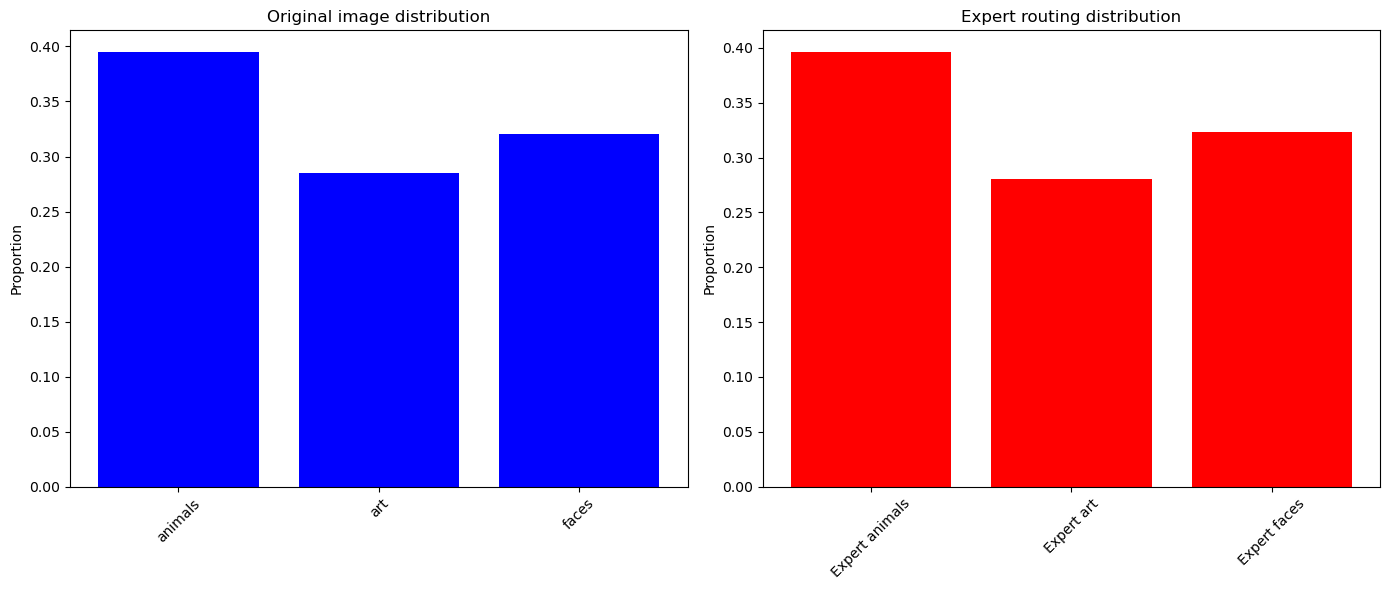

In [41]:
expert_distribution = metrics['expert_distribution']

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].bar(high_level_names, original_distribution_norm, color='blue')
axs[0].set_title('Original image distribution')
axs[0].set_ylabel('Proportion')
axs[0].set_xticklabels(high_level_names, rotation=45)

axs[1].bar([f'Expert {experts_names[i]}' for i in range(len(expert_distribution))], expert_distribution, color='red')
axs[1].set_title('Expert routing distribution')
axs[1].set_ylabel('Proportion')
axs[1].set_xticklabels([f'Expert {experts_names[i]}' for i in range(len(expert_distribution))], rotation=45)

plt.tight_layout()
plt.show()